=== ret_next ===
  fold 0: train n= 25  test n= 20  slope=+0.024
  fold 1: train n= 45  test n= 20  slope=+0.012
  fold 2: train n= 65  test n= 20  slope=+0.006
  fold 3: train n= 85  test n= 20  slope=-0.008
  fold 4: train n=105  test n= 20  slope=-0.003
  --- ret_next out-of-sample ---
  RMSE model = 1.647%   RMSE naive(mean) = 1.566%
  R2 (model vs mean) = -0.1524
  -> R2<=0 means the model does NOT beat just predicting the average

=== ret ===
  fold 0: train n= 25  test n= 20  slope=-0.004
  fold 1: train n= 45  test n= 20  slope=-0.002
  fold 2: train n= 65  test n= 20  slope=+0.000
  fold 3: train n= 85  test n= 20  slope=+0.002
  fold 4: train n=105  test n= 20  slope=+0.001
  --- ret out-of-sample ---
  RMSE model = 1.126%   RMSE naive(mean) = 1.123%
  R2 (model vs mean) = -0.0215
  -> R2<=0 means the model does NOT beat just predicting the average



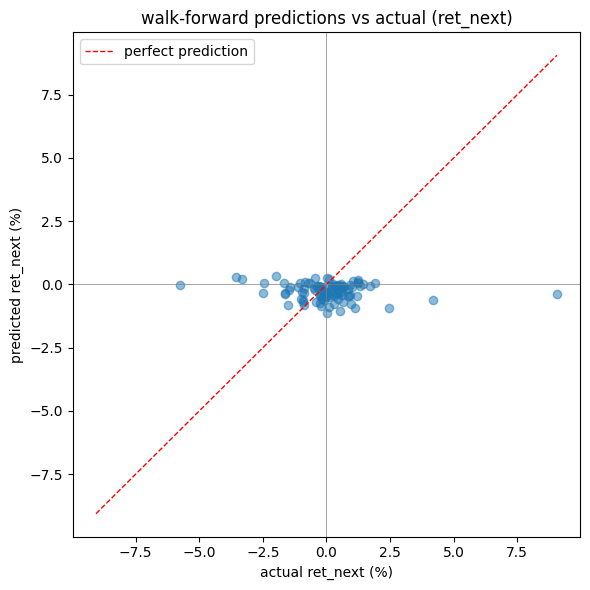

In [2]:
# linear regression baseline with walk-forward (expanding window) CV
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor              # the "just predict the mean" baseline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

fomc = pd.read_csv("../data/processed/fomc_spy.csv")
fomc["date"] = pd.to_datetime(fomc["date"]).dt.normalize()
fomc = fomc.sort_values("date").reset_index(drop=True)   # CRITICAL: time order for walk-forward

# single feature for the baseline: sentiment (avoid the compositional prob cols -> multicollinearity)
FEATURES = ["sentiment"]

def walk_forward(target):
    df = fomc.dropna(subset=FEATURES + [target]).reset_index(drop=True)
    X = df[FEATURES].values
    y = df[target].values

    # expanding window: TimeSeriesSplit grows the train set each fold, test is always future
    tscv = TimeSeriesSplit(n_splits=5)

    preds, truths, naive_preds = [], [], []
    for fold, (tr_idx, te_idx) in enumerate(tscv.split(X)):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        # real model
        model = LinearRegression().fit(X_tr, y_tr)
        # naive baseline: predict the TRAIN mean (no leakage — mean from train only)
        dummy = DummyRegressor(strategy="mean").fit(X_tr, y_tr)

        preds.extend(model.predict(X_te))
        naive_preds.extend(dummy.predict(X_te))
        truths.extend(y_te)
        print(f"  fold {fold}: train n={len(tr_idx):3d}  test n={len(te_idx):3d}  "
              f"slope={model.coef_[0]:+.3f}")

    preds, truths, naive_preds = map(np.array, (preds, truths, naive_preds))

    # out-of-sample scoring: model vs naive baseline
    rmse_model = np.sqrt(mean_squared_error(truths, preds))
    rmse_naive = np.sqrt(mean_squared_error(truths, naive_preds))
    r2_model   = r2_score(truths, preds)        # vs predicting the mean
    print(f"  --- {target} out-of-sample ---")
    print(f"  RMSE model = {rmse_model*100:.3f}%   RMSE naive(mean) = {rmse_naive*100:.3f}%")
    print(f"  R2 (model vs mean) = {r2_model:+.4f}")
    print(f"  -> R2<=0 means the model does NOT beat just predicting the average")
    print()
    return truths, preds

print("=== ret_next ===")
t1, p1 = walk_forward("ret_next")
print("=== ret ===")
t2, p2 = walk_forward("ret")

# visualize predicted vs actual for ret_next
plt.figure(figsize=(6,6))
plt.scatter(t1*100, p1*100, alpha=0.5)
lim = max(abs(t1).max(), abs(p1).max())*100
plt.plot([-lim,lim],[-lim,lim], 'r--', lw=1, label="perfect prediction")
plt.axhline(0, color='gray', lw=0.5); plt.axvline(0, color='gray', lw=0.5)
plt.xlabel("actual ret_next (%)"); plt.ylabel("predicted ret_next (%)")
plt.title("walk-forward predictions vs actual (ret_next)")
plt.legend(); plt.tight_layout(); plt.show()